In [1]:
!pip install -q kaggle

In [4]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"norawael","key":"d72669b024e44e607fcfa0a52a0489fe"}'}

In [5]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API is ready.")

Kaggle API is ready.


In [6]:
!kaggle datasets download -d kamilpytlak/personal-key-indicators-of-heart-disease --unzip

Dataset URL: https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
License(s): CC0-1.0
100% 21.4M/21.4M [00:02<00:00, 8.28MB/s]



In [7]:
import os

os.listdir()

['.config', 'kaggle (1).json', '2020', 'kaggle.json', '2022', 'sample_data']

In [8]:
import pandas as pd

df = pd.read_csv('/content/2020/heart_2020_cleaned.csv')

df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [10]:
print(df.shape)

df.info()

(319795, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyD

In [11]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,5,2,1,4,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,5,0,1,4,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,5,2,1,1,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,5,0,0,2,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,5,0,1,4,8.0,0,0,0


In [12]:
features = [
    'BMI',
    'Smoking',
    'AlcoholDrinking',
    'Stroke',
    'PhysicalHealth',
    'MentalHealth',
    'DiffWalking',
    'Sex',
    'AgeCategory',
    'Race',
    'Diabetic',
    'PhysicalActivity',
    'GenHealth',
    'SleepTime',
    'Asthma',
    'KidneyDisease',
    'SkinCancer'
]

X = df_encoded[features]

y = df_encoded['HeartDisease']

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [15]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='auc',
    random_state=42
)

In [16]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='auc',
    random_state=42
)

In [17]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [18]:
y_pred_proba = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_pred_proba)

print("AUC Score:", auc)

AUC Score: 0.9342247844057482


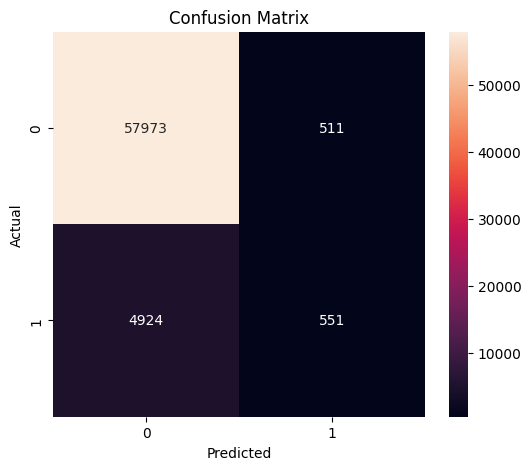

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
def get_recommendations(patient):
    recommendations = []

    if patient['Smoking'] == 1:
        recommendations.append("Stop smoking because it increases cardiovascular risk.")

    if patient['BMI'] >= 30:
        recommendations.append("Work on weight reduction through healthy diet and regular exercise.")

    if patient['PhysicalActivity'] == 0:
        recommendations.append("Increase physical activity, such as walking 30 minutes daily.")

    if patient['SleepTime'] < 6:
        recommendations.append("Improve sleep duration to at least 7 hours per night.")

    if patient['AlcoholDrinking'] == 1:
        recommendations.append("Reduce alcohol consumption to lower heart risk.")

    if patient['Diabetic'] != 0:
        recommendations.append("Monitor blood glucose regularly and follow diabetes care plan.")

    if patient['KidneyDisease'] == 1:
        recommendations.append("Follow up with a doctor because kidney disease increases heart risk.")

    if patient['Stroke'] == 1:
        recommendations.append("Regular cardiovascular follow-up is strongly recommended.")

    if len(recommendations) == 0:
        recommendations.append("Maintain healthy lifestyle and regular checkups.")

    return recommendations

In [39]:
import random

# Random patient
random_index = random.randint(0, len(X_test)-1)

sample_patient = X_test.iloc[random_index]

# Prediction
risk_probability = model.predict_proba([sample_patient])[0][1]

prediction = model.predict([sample_patient])[0]

print("Risk Probability:", round(risk_probability * 100, 2), "%")

if prediction == 1:
    print("Prediction: High Heart Disease Risk")
else:
    print("Prediction: Low Heart Disease Risk")

print("\nRecommendations:")

for rec in get_recommendations(sample_patient):
    print("-", rec)

Risk Probability: 11.95 %
Prediction: Low Heart Disease Risk

Recommendations:
- Stop smoking because it increases cardiovascular risk.
- Reduce alcohol consumption to lower heart risk.


In [43]:
import random

random_index = random.randint(0, len(X_test)-1)

sample_patient = X_test.iloc[random_index]

risk_probability = model.predict_proba([sample_patient])[0][1]

print("Risk Probability:", round(risk_probability * 100, 2), "%")

if risk_probability >= 0.30:
    print("Prediction: High Heart Disease Risk")
else:
    print("Prediction: Low Heart Disease Risk")

print("\nRecommendations:")

for rec in get_recommendations(sample_patient):
    print("-", rec)

Risk Probability: 0.33 %
Prediction: Low Heart Disease Risk

Recommendations:
- Stop smoking because it increases cardiovascular risk.


In [44]:
balanced_df = pd.DataFrame(X_resampled, columns=X.columns)

balanced_df['HeartDisease'] = y_resampled

balanced_df.head()

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,16.60,1,0,0,3.0,30.0,0,0,7,5,2,1,4,5.0,1,0,1,0
1,20.34,0,0,1,0.0,0.0,0,0,12,5,0,1,4,7.0,0,0,0,0
2,26.58,1,0,0,20.0,30.0,0,1,9,5,2,1,1,8.0,1,0,0,0
3,24.21,0,0,0,0.0,0.0,0,0,11,5,0,0,2,6.0,0,0,1,0
4,23.71,0,0,0,28.0,0.0,1,0,4,5,0,1,4,8.0,0,0,0,0


In [45]:
balanced_df.to_csv("balanced_heart_disease_dataset.csv", index=False)

print("Balanced dataset saved successfully.")

Balanced dataset saved successfully.


In [46]:
from google.colab import files

files.download("balanced_heart_disease_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>